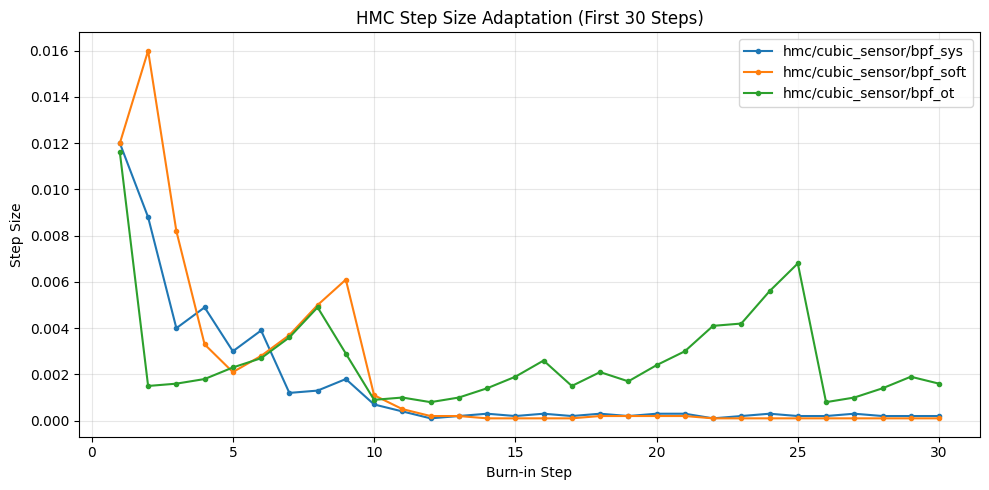

In [2]:
import re
import matplotlib.pyplot as plt

# Parse the log file
with open('../run_dpf_sv_cubic.txt', 'r') as f:
    text = f.read()

# Split by experiment headers
experiments = re.split(r'={40}\n\[\d+/\d+\]\s+', text)[1:]  # skip preamble

# Extract name and step sizes for first 3 experiments
names = []
step_sizes = []
for exp in experiments[:3]:
    # Get experiment name from first line
    name = exp.split('\n')[0].strip().strip('=')
    names.append(name)
    # Extract step_size values
    sizes = [float(m) for m in re.findall(r'step_size=([\d.]+)', exp)]
    step_sizes.append(sizes[:30])

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for name, sizes in zip(names, step_sizes):
    ax.plot(range(1, len(sizes) + 1), sizes, marker='o', markersize=3, label=name)

ax.set_xlabel('Burn-in Step')
ax.set_ylabel('Step Size')
ax.set_title('HMC Step Size Adaptation (First 30 Steps)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stepsize_resampling.png', dpi=300, bbox_inches='tight')
plt.show()